In [1]:
from datasets import get_test_loader, synsetid_to_cate
import torch
import gudhi
import matplotlib.pyplot as plt

import torch.nn as nn
from models.networks import PointFlow
from models.vae import BaseModel as VAE
from models.encoder import BaseModel as Encoder
from models.encoder_extended import BaseModel as EncoderExtended
from model_wrapper import TopologicalModelVAE, TopologicalModelEncoder, ShapeNetModel, TopologicalModelEncoderScaled
from models.networks import PointFlow
from load_model_scaled import load_encoder
from args import get_parser
from plot_utils import plot_pcs_recon
import  matplotlib.pyplot as plt
import umap
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import pyvista as pv
pv.set_jupyter_backend('static')

%matplotlib inline

In [2]:


def load_model(args):
    # Load the model 
    if args.model == "Encoder": 
        print("Loading Encoder")
        encoder_model = Encoder.load_from_checkpoint(
            checkpoint_path=f"./trained_models/ectencoder_shapenet_{args.cates[0]}.ckpt"
        ).cuda()
        model = TopologicalModelEncoder(encoder_model.cuda())
    elif args.model == "EncoderExtended": 
        print("Loading EncoderExtended")
        encoder_model = EncoderExtended.load_from_checkpoint(
            checkpoint_path=f"./trained_models/ectencoder_shapenet_{args.cates[0]}_extended.ckpt"
        ).cuda()
        model = TopologicalModelEncoder(encoder_model.cuda())
    elif args.model == "EncoderScaled": 
        print("Loading EncoderScaled")
        path = f"./configs/config_encoder_shapenet_{args.cates[0]}_scaled.yaml"
        encoder = load_encoder(path)
        model = TopologicalModelEncoderScaled(encoder.cuda(),args.normalize)

    elif args.model == "EncoderScaledBase": 
        print("Loading EncoderScaledBase")
        path = f"./configs/config_encoder_shapenet_{args.cates[0]}_scaled_base.yaml"
        encoder = load_encoder(path)
        model = TopologicalModelEncoderScaled(encoder.cuda(),args.normalize)
    elif args.model == "VAE":
        print("Loading VAE")
        encoder_model = Encoder.load_from_checkpoint(
            checkpoint_path=f"./trained_models/ectencoder_shapenet_{args.cates[0]}.ckpt"
        ).cuda()
        vae = VAE.load_from_checkpoint(
            f"./trained_models/vae_shapenet_{args.cates[0]}.ckpt"
        ).cuda()
        model = TopologicalModelVAE(encoder_model, vae)
        model.vae.eval()
    elif args.model == "PointFlow":
        model = PointFlow(args)

        def _transform_(m):
            return nn.DataParallel(m, device_ids=[0])

        model = model.cuda()
        model.multi_gpu_wrapper(_transform_)

        print("Resume Path:%s" % args.resume_checkpoint)
        checkpoint = torch.load(args.resume_checkpoint)
        model.load_state_dict(checkpoint)
        model.eval()
    elif args.model == "ShapeNet-0":
        model = ShapeNetModel(noise=0)
    elif args.model == "ShapeNet-005":
        model = ShapeNetModel(noise=.005)
    elif args.model == "ShapeNet-01":
        model = ShapeNetModel(noise=.01)
    else: 
        raise ValueError()
    return model 



In [3]:
model = "VAE"
p = get_parser()
args, unknown = p.parse_known_args({"fast_run":False})
args.model = model
args.cates = ["airplane"]
model = load_model(args)

Loading VAE


C:\Users\ernst\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.3.3, which is newer than your current Lightning version: v2.2.3


In [4]:
print("=====GEN======")
loader = get_test_loader(args)
all_ect = []
all_recon_ect = []
tr_pcs = []
mus, lvs = [],[]
rc_pcs = []
with torch.no_grad():
    for data in loader:
        idx_b, tr_pc, te_pc = data["idx"], data["train_points"], data["test_points"]

        te_pc = te_pc.cuda() if args.gpu is None else te_pc.cuda(args.gpu)
        tr_pc = tr_pc.cuda() if args.gpu is None else tr_pc.cuda(args.gpu)
        B, N = te_pc.size(0), te_pc.size(1)
        recon_ect, ect,mu,lv = model.reconstruct_vae(tr_pc, num_points=N)
        out_pc = model.reconstruct(tr_pc, num_points=N)
        mus.append(mu)
        lvs.append(lv)
        all_ect.append((ect + 1 ) / 2)
        all_recon_ect.append((recon_ect + 1 ) / 2)
        tr_pcs.append(tr_pc)
        rc_pcs.append(out_pc)

ref_ect = torch.cat(all_ect, dim=0)
recon_ect = torch.cat(all_recon_ect, dim=0)
ref_pcs =torch.cat(tr_pcs,dim=0)
recon_pcs = torch.cat(rc_pcs,dim=0)
mu_vector = torch.cat(mus,dim=0).cpu().numpy()
logvar_vector = torch.cat(lvs,dim=0).cpu().numpy()

=====GEN======
Total number of data:2832
Min number of points: (train)2048 (test)2048
Total number of data:405
Min number of points: (train)2048 (test)2048


In [5]:
sample_ect, sample_pc = model.sample(10,2048)

In [6]:
torch.save(ref_ect,"./recon/ref_ect.pt")
torch.save(recon_ect,"./recon/recon_ect.pt")
torch.save(ref_pcs,"./recon/ref_pcs.pt")
torch.save(recon_pcs,"./recon/recon_pcs.pt")

torch.save(sample_ect,"./recon/sample_ect.pt")
torch.save(sample_pc,"./recon/sample_pc.pt")


# Embed paths from the ambient space into the latent space 

We interpolate between ect's and map them to the latent space

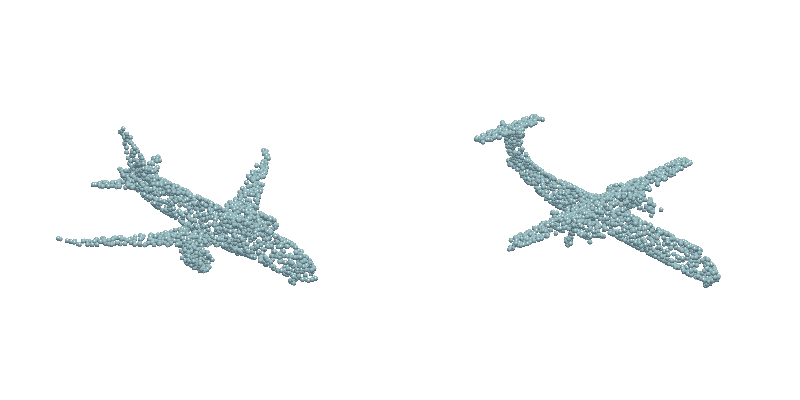

In [62]:
START = 31
END = 34
# START = 17
# END = 10

pl = pv.Plotter(shape=(1,2), window_size=[800, 400],border=False,polygon_smoothing=True)

points = ref_pcs[START].reshape(-1, 3).detach().cpu().numpy()
pl.subplot(0, 0)
actor = pl.add_points(
    points,
    style="points",
    emissive=False,
    show_scalar_bar=False,
    render_points_as_spheres=True,
    color="lightblue",
    point_size=5,
    ambient=0.2, 
    diffuse=0.8, 
    specular=0.8,
    specular_power=40, 
    smooth_shading=True
)
points = ref_pcs[END].reshape(-1, 3).detach().cpu().numpy()
pl.subplot(0, 1)
actor = pl.add_points(
    points,
    style="points",
    emissive=False,
    show_scalar_bar=False,
    render_points_as_spheres=True,
    color="lightblue",
    point_size=5,
    ambient=0.2, 
    diffuse=0.8, 
    specular=0.8,
    specular_power=40, 
    smooth_shading=True
)
pl.background_color = "w"
pl.link_views()
pl.camera_position = "xy"
pos = pl.camera.position
pl.camera.position = (pos[0],pos[1]+3,pos[2])
pl.camera.position = (20,0,0)
pl.camera.azimuth = 45
pl.camera.elevation = 30
# create a top down light
light = pv.Light(position=(0, 0, 0), positional=True,
                cone_angle=50, exponent=20, intensity=.2)
pl.add_light(light)
pl.camera.zoom(1.3)
pl.show()

# ECT Interpolation

In [60]:
with torch.no_grad():
    t = torch.tensor(np.linspace(0,1,16,endpoint=True)).view(-1,1,1).cuda()
    ect_interp = (t * ref_ect[START].repeat((16,1,1)) + (1-t) * ref_ect[END].repeat((16,1,1))).to(torch.float32)
    ect_interp_pc = model.encoder(ect_interp)
   

In [64]:
np.save(f"interpolation_airplane.npy",ect_interp_pc.cpu().detach().numpy())

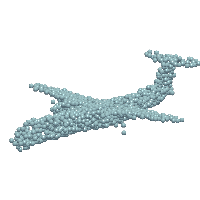

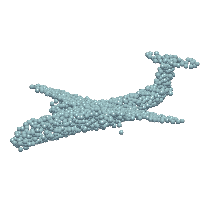

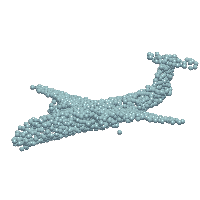

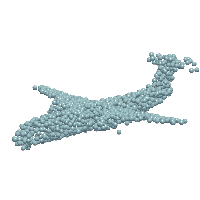

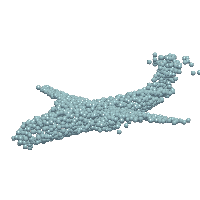

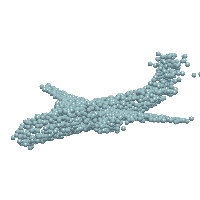

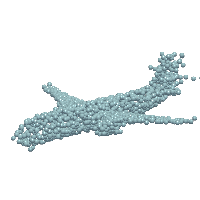

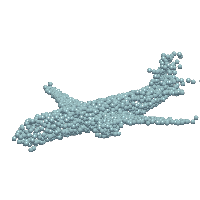

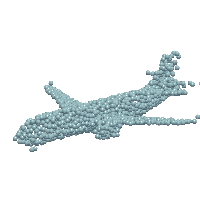

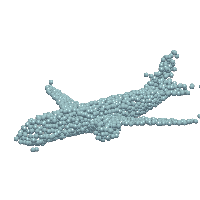

In [63]:

for idx in range(10):
    pl = pv.Plotter(shape=(1,1), window_size=[200, 200],border=False,polygon_smoothing=True)
    points = ect_interp_pc[idx].reshape(-1, 3).detach().cpu().numpy()
    pl.subplot(0, 0)
    actor = pl.add_points(
        points,
        style="points",
        emissive=False,
        show_scalar_bar=False,
        render_points_as_spheres=True,
        color="lightblue",
        point_size=5,
        ambient=0.2, 
        diffuse=0.8, 
        specular=0.8,
        specular_power=40, 
        smooth_shading=True
    )
    pl.background_color = "w"
    pl.link_views()
    pl.camera_position = "xy"
    pos = pl.camera.position
    pl.camera.position = (pos[0],pos[1]+3,pos[2])
    pl.camera.position = (30,0,0)
    pl.camera.azimuth = 135
    pl.camera.elevation = 15
    # create a top down light
    light = pv.Light(position=(0, 0, 0), positional=True,
                    cone_angle=50, exponent=20, intensity=.2)
    pl.add_light(light)
    pl.camera.zoom(3)
    pl.show()
    pl.screenshot(f"./figures/airplane_interpolation_{idx}.png",transparent_background=True)
    pl.clear()



# Latent Interpolation

In [9]:
s = torch.tensor(np.linspace(0,1,100,endpoint=True)).unsqueeze(1).cuda()
latent_path_straight = (latent_path[0].unsqueeze(0) * s + (1-s)*latent_path[-1].unsqueeze(0)).to(torch.float)

with torch.no_grad():
    ect_interp_straight = (model.vae.model.decode(latent_path_straight)+1)/2
    # res,_,_,_ = model.vae(2*ect_recon.unsqueeze(1)-1)
    latent_path_straight_pc = model.encoder(ect_interp_straight)

In [10]:
torch.norm(latent_path_straight[-1]-latent_path[0])

tensor(0., device='cuda:0')

In [11]:
assert torch.allclose(ect_interp.min(),torch.tensor(0.0))
assert torch.allclose(ect_interp_straight.min(),torch.tensor(0.0),atol=1e-6)
assert torch.allclose(ect_interp_recon.min(),torch.tensor(0.0),atol=1e-6)


assert torch.allclose(ect_interp.max(),torch.tensor(1.0))
assert torch.allclose(ect_interp_straight.max(),torch.tensor(1.0),atol=1e-6)
assert torch.allclose(ect_interp_recon.max(),torch.tensor(1.0),atol=1e-6)

# assert ect_interp.max() == 1
# assert ect_interp_straight.max() == 1
# assert ect_interp_recon.max() == 1

In [29]:
# Encode all paths with the encoder

with torch.no_grad():
    ect_interp_straight_pc = model.encoder(ect_interp_straight)
    ect_interp_pc = model.encoder(ect_interp)
    ect_interp_recon_pc = model.encoder(ect_interp_recon)

# Plot Latent Space

In [13]:
# pca = PCA(n_components=100)
# sc = StandardScaler()
# sc.fit(z_vector)
# data_scaled = sc.transform(z_vector)
# pca.fit_transform(data_scaled)
# z_vector_pca = pca.transform(data_scaled)

pca = PCA(n_components=100)
pca.fit_transform(z_vector)
z_vector_pca = pca.transform(z_vector)


In [14]:
latent_path_pca = pca.transform(latent_path.cpu().numpy())
latent_path_straigh_pca = pca.transform(latent_path_straight.cpu().numpy())


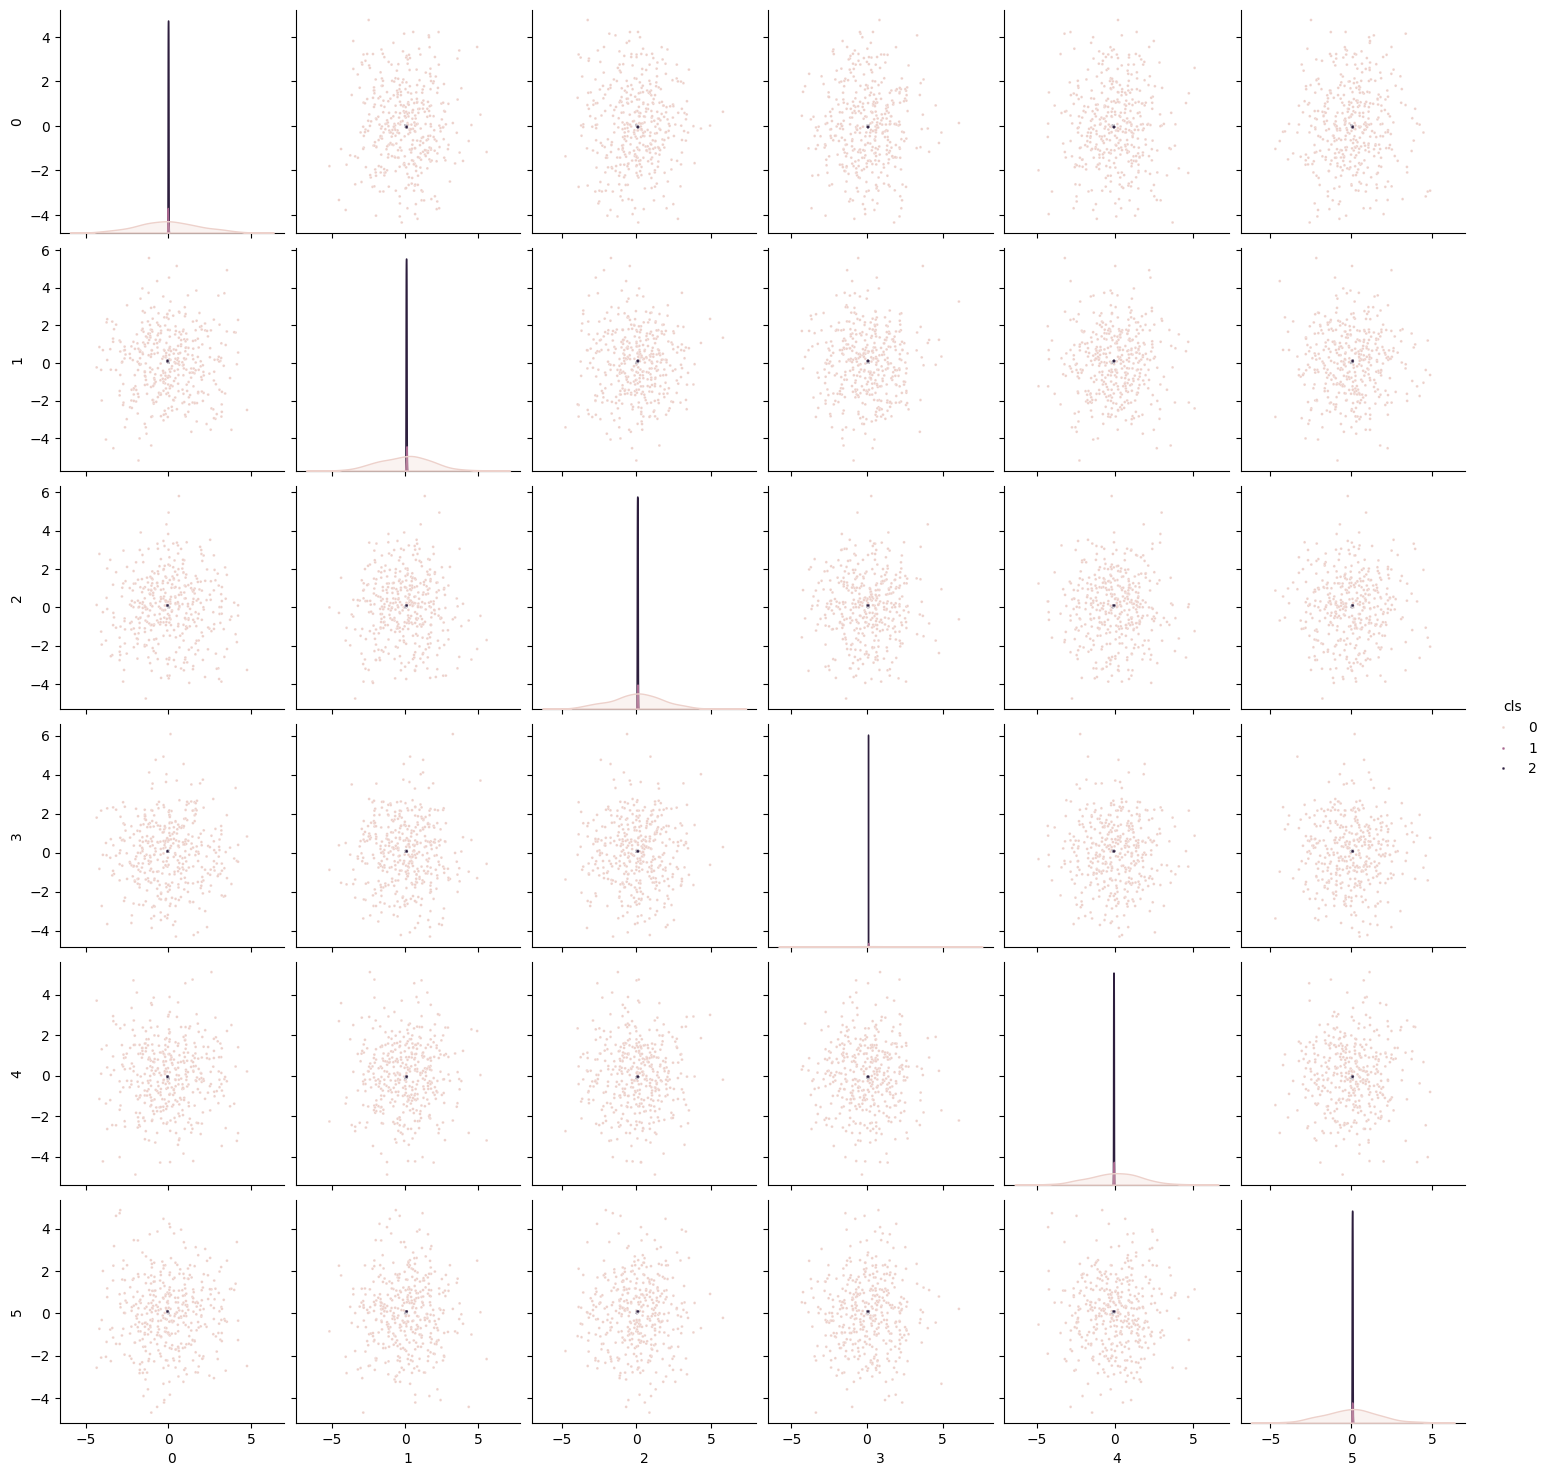

In [15]:
z_vector_df = pd.DataFrame(z_vector_pca)
z_vector_df["cls"] = 0

latent_path_pca_df = pd.DataFrame(latent_path_pca)
latent_path_pca_df["cls"] = 1
latent_path_straigh_pca_df = pd.DataFrame(latent_path_straigh_pca)
latent_path_straigh_pca_df["cls"] = 2


df = pd.concat([z_vector_df, latent_path_pca_df, latent_path_straigh_pca_df])

import matplotlib as mpl
mpl.rcParams['lines.markersize'] = 2
sns.pairplot(df,x_vars=[0,1,2,3,4,5],y_vars=[0,1,2,3,4,5],hue="cls")

# ECT Interpolation

In [16]:
# with torch.no_grad():
#     ect_interp_straight_pc = model.encoder(ect_interp_straight)
#     ect_interp_pc = model.encoder(ect_interp)
#     ect_interp_recon_pc = model.encoder(ect_interp_recon)

In [30]:
ect_interp_pc.shape

torch.Size([10, 6144])

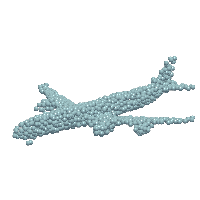

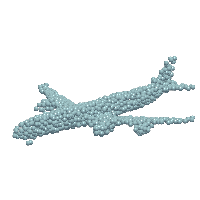

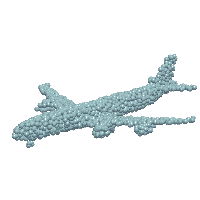

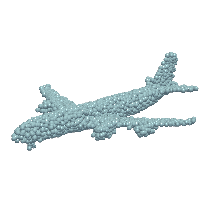

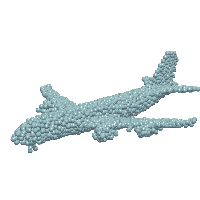

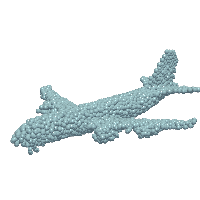

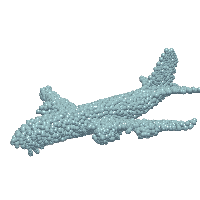

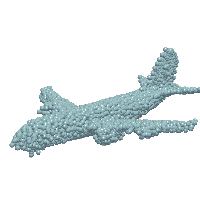

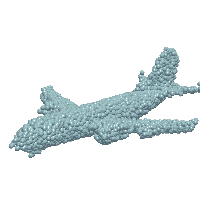

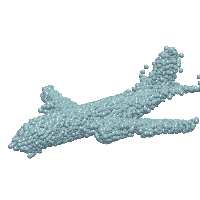

In [17]:
# from fastapi import background


pl = pv.Plotter(shape=(1,1), window_size=[200, 200],border=False,polygon_smoothing=True)
for idx in range(10):
    points = ect_interp_pc[idx].reshape(-1, 3).detach().cpu().numpy()
    pl.subplot(0, 0)
    actor = pl.add_points(
        points,
        style="points",
        emissive=False,
        show_scalar_bar=False,
        render_points_as_spheres=True,
        color="lightblue",
        point_size=5,
        ambient=0.2, 
        diffuse=0.8, 
        specular=0.8,
        specular_power=40, 
        smooth_shading=True
    )
    pl.background_color = "w"
    pl.link_views()
    pl.camera_position = "xy"
    pos = pl.camera.position
    pl.camera.position = (pos[0],pos[1]+3,pos[2])
    pl.camera.position = (30,0,0)
    pl.camera.azimuth = 135
    pl.camera.elevation = 15
    # create a top down light
    light = pv.Light(position=(0, 0, 0), positional=True,
                    cone_angle=50, exponent=20, intensity=.2)
    pl.add_light(light)
    pl.camera.zoom(3)
    pl.show()
    pl.screenshot(f"./figures/airplane_interpolation_{idx}.png",transparent_background=True)

<Axes: >

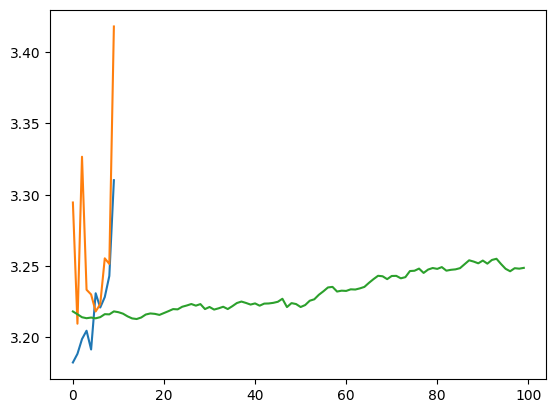

In [18]:
# with torch.no_grad():
#     ect_interp_straight_pc = model.encoder(ect_interp_straight)
#     ect_interp_pc = model.encoder(ect_interp)
#     ect_interp_recon_pc = model.encoder(ect_interp_recon)

entropy_ect_interp = []
for lpc in ect_interp_pc:
    data = lpc.view(-1,3).cpu().detach()
    hist = np.histogramdd(np.array(data))[0]
    hist /= hist.sum()
    hist = hist.flatten()
    hist = hist[hist.nonzero()]
    entropy_ect_interp.append( -0.5 * np.sum(hist * np.log2(hist)))
entropy_ect_interp = np.array(entropy_ect_interp)


entropy_ect_interp_recon = []
for lpc in ect_interp_recon_pc:
    data = lpc.view(-1,3).cpu().detach()
    hist = np.histogramdd(np.array(data))[0]
    hist /= hist.sum()
    hist = hist.flatten()
    hist = hist[hist.nonzero()]
    entropy_ect_interp_recon.append( -0.5 * np.sum(hist * np.log2(hist)))
entropy_ect_interp_recon = np.array(entropy_ect_interp_recon)

entropy_ect_interp_straight = []
for lpc in ect_interp_straight_pc:
    data = lpc.view(-1,3).cpu().detach()
    hist = np.histogramdd(np.array(data))[0]
    hist /= hist.sum()
    hist = hist.flatten()
    hist = hist[hist.nonzero()]
    entropy_ect_interp_straight.append( -0.5 * np.sum(hist * np.log2(hist)))
entropy_ect_interp_straight = np.array(entropy_ect_interp_straight[::-1])

sns.lineplot(entropy_ect_interp)
sns.lineplot(entropy_ect_interp_recon)
sns.lineplot(entropy_ect_interp_straight)

# Reconstruct this path with the VAE

In [19]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

In [20]:
# sns.lineplot(entropy_ect_interp)
# sns.lineplot(entropy_ect_interp_recon)
# sns.lineplot(entropy_ect_interp_straight)

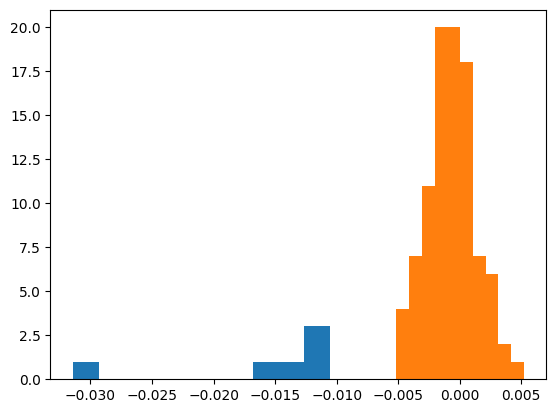

In [21]:
w = 5
entropy_ect_interp_avg = moving_average(entropy_ect_interp,w)
entropy_ect_interp_recon_avg = moving_average(entropy_ect_interp_recon,w)
entropy_ect_interp_straight_avg = moving_average(entropy_ect_interp_straight,w)


plt.hist(entropy_ect_interp[:-4]-entropy_ect_interp_avg);
# plt.hist(entropy_ect_interp_recon[:-4]-entropy_ect_interp_recon_avg);
plt.hist(entropy_ect_interp_straight[:-4]-entropy_ect_interp_straight_avg);

In [22]:
# np.array(entropy_encoder)

# Do clustering on the latent space with ToMaTo


In [23]:
z_vector

tensor([[-1.0314,  0.5813,  0.0298,  ...,  1.3724,  0.3601, -0.5594],
        [ 0.8571, -1.1724, -0.9919,  ..., -0.6460,  0.3552, -1.0027],
        [ 0.9568,  0.7224, -0.0658,  ...,  1.1908,  1.1033,  0.4879],
        ...,
        [-0.3634, -0.7492, -0.3986,  ..., -0.1302, -0.2418,  0.4048],
        [ 1.0188,  0.3840,  0.0993,  ...,  0.6348,  1.1319, -0.7186],
        [-2.6916, -0.8778,  0.6522,  ..., -0.5270,  0.5815,  0.1764]])

<Axes: >

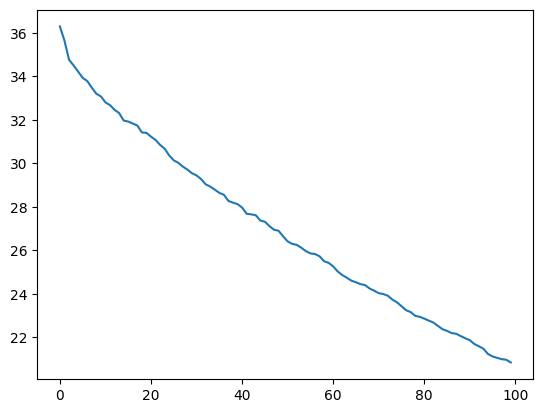

In [24]:
from sklearn.preprocessing import StandardScaler

def project(data):
    pca = PCA(n_components=100)
    sc = StandardScaler()
    sc.fit(data)
    data_scaled = sc.transform(data)
    pca.fit_transform(data_scaled)
    return pca.transform(data_scaled),pca.singular_values_

lv_pca, sv = project(z_vector)

sns.lineplot(sv)

In [25]:
# from gudhi.clustering.tomato import Tomato
# t = Tomato(density_type='KDE', k=10)
# t.fit(lv_pca)
# t.plot_diagram()

In [26]:

# latent_df = pd.DataFrame(lv_pca)
# latent_df["cls"] = t.labels_
# # latent_df["cls"] = 0
# latent_df


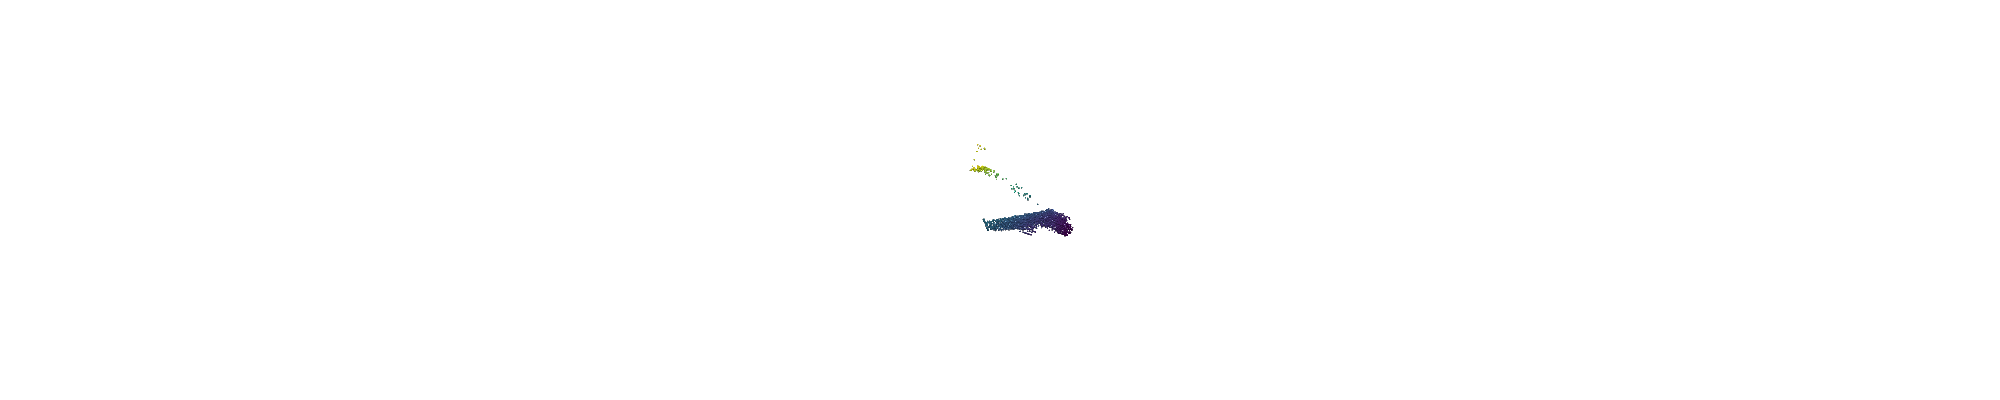

In [27]:
pcs = []

#     ect_interp_straight_pc = model.encoder(ect_interp_straight)
#     ect_interp_pc = model.encoder(ect_interp)
#     ect_interp_recon_pc = model.encoder(ect_interp_recon)




for pc in ect_interp_pc:
    idx = pc.view(-1,3)[:,0] >.5
    pcs.append(pc.view(-1,3)[idx])

points = torch.vstack(pcs).cpu().numpy()




pl = pv.Plotter(shape=(1,1), window_size=[2000, 400],border=False,polygon_smoothing=True)

pl.subplot(0, 0)
actor = pl.add_points(
    points,
    style="points",
    emissive=False,
    show_scalar_bar=False,
    render_points_as_spheres=True,
    scalars=points[:, 2],
    point_size=2,
    ambient=0.2, 
    diffuse=0.8, 
    specular=0.8,
    specular_power=40, 
    smooth_shading=True
)

pl.background_color = "w"
pl.link_views()
pl.camera_position = "xy"
pos = pl.camera.position
pl.camera.position = (pos[0],pos[1]+3,pos[2])
pl.camera.position = (30,0,0)
pl.camera.azimuth = 45
pl.camera.elevation = 30
# create a top down light
light = pv.Light(position=(0, 0, 0), positional=True,
                cone_angle=50, exponent=20, intensity=.2)
pl.add_light(light)
pl.camera.zoom(1.3)
pl.show()
